In [140]:
# importing required libraries
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [141]:
# importing data
df_chemicals_water = pd.read_csv('Waterbase_data.csv')
df_chemicals_water.head()

,countryCode,waterBodyIdentifier,waterBodyIdentifierScheme,parameterWaterBodyCategory,observedPropertyDeterminandCode,observedPropertyDeterminandLabel,procedureAnalysedMatrix,resultUom,phenomenonTimeReferenceYear,parameterSamplingPeriod,...,resultNumberOfSitesClass4,resultNumberOfSitesClass5,resultObservationStatus,remarks,metadata_versionId,metadata_beginLifeSpanVersion,metadata_statusCode,metadata_observationStatus,metadata_statements,UID
0,BG,BG096,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,1991,1991-01-01--1991-12-31,...,1.0,1.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,2667
1,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2009,2009-01-01--2009-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12234
2,BG,BG3G000000Q010,euGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,2002,2002-01-01--2002-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,4282
3,FI,FI034,eionetGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,1989,1989-01-01--1989-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,13263
4,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2010,2010-01-01--2010-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12235


In [142]:
df_chemicals_water.describe()

,phenomenonTimeReferenceYear,procedureLOQValue,resultNumberOfSamples,resultQualityNumberOfSamplesBelowLOQ,resultQualityMinimumBelowLOQ,resultMinimumValue,resultQualityMeanBelowLOQ,resultMeanValue,resultQualityMaximumBelowLOQ,resultMaximumValue,resultQualityMedianBelowLOQ,resultMedianValue,resultStandardDeviationValue,resultNumberOfSitesClass1,resultNumberOfSitesClass2,resultNumberOfSitesClass3,resultNumberOfSitesClass4,resultNumberOfSitesClass5,UID
count,20783.000000,20693.000000,20783.000000,20701.000000,2559.000000,19884.000000,2559.000000,20776.000000,2559.000000,20153.000000,2559.000000,14691.000000,2291.000000,20330.000000,20202.000000,20206.000000,17118.000000,4425.000000,20783.000000
mean,2004.651831,1.870076,37.490497,6.693735,0.666276,4.744976,0.121532,8.371677,0.063306,21.833574,0.296600,8.386409,10.044922,8.256763,3.999059,2.473572,3.465417,2.361130,19844.153876
std,8.349417,30.105165,153.664652,56.267355,0.471635,17.815899,0.326808,22.225000,0.243560,72.967333,0.456848,23.719555,26.280361,24.305022,15.272864,8.528037,13.782762,11.645193,11121.872270
min,1980.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000020,0.000000,0.000020,0.000000,0.000500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1998.000000,0.000000,1.000000,0.000000,0.000000,0.010000,0.000000,0.025000,0.000000,0.050000,0.000000,0.030000,0.160000,0.000000,0.000000,0.000000,0.000000,0.000000,12803.500000
50%,2006.000000,0.000000,1.000000,0.000000,1.000000,0.098000,0.000000,0.424500,0.000000,1.349000,0.000000,0.469000,1.571000,1.000000,0.000000,0.000000,0.000000,0.000000,19851.000000
75%,2010.000000,0.000000,5.000000,0.000000,1.000000,2.575175,0.000000,7.083575,0.000000,10.000000,1.000000,6.800000,9.366996,4.000000,2.000000,1.000000,1.000000,1.000000,28202.500000
max,2022.000000,502.000000,1508.000000,1397.000000,1.000000,423.000000,1.000000,423.000000,1.000000,2082.400000,1.000000,423.000000,650.220447,673.000000,350.000000,215.000000,268.000000,253.000000,45031.000000


In [143]:
# checking for duplicate Rows
print(df_chemicals_water[df_chemicals_water.duplicated()])

Empty DataFrame
Columns: [countryCode, waterBodyIdentifier, waterBodyIdentifierScheme, parameterWaterBodyCategory, observedPropertyDeterminandCode, observedPropertyDeterminandLabel, procedureAnalysedMatrix, resultUom, phenomenonTimeReferenceYear, parameterSamplingPeriod, procedureLOQValue, resultNumberOfSamples, resultQualityNumberOfSamplesBelowLOQ, resultQualityMinimumBelowLOQ, resultMinimumValue, resultQualityMeanBelowLOQ, resultMeanValue, resultQualityMaximumBelowLOQ, resultMaximumValue, resultQualityMedianBelowLOQ, resultMedianValue, resultStandardDeviationValue, resultNumberOfSitesClass1, resultNumberOfSitesClass2, resultNumberOfSitesClass3, resultNumberOfSitesClass4, resultNumberOfSitesClass5, resultObservationStatus, remarks, metadata_versionId, metadata_beginLifeSpanVersion, metadata_statusCode, metadata_observationStatus, metadata_statements, UID]
Index: []

[0 rows x 35 columns]


In [144]:
# getting numerical and categorical columns 
cat_cols = df_chemicals_water.select_dtypes(object).columns
num_cols = df_chemicals_water.select_dtypes(np.number).columns

# prinitng numerical columns
print("Dataset has following Numerical columns")
for i, j in enumerate(num_cols):
    print(f" {i+1}) {j}")

# printing categorical columns
print("\n\nDataset has following Categorical columns")
for i, j in enumerate(cat_cols):
    print(f" {i+1}) {j}")

Dataset has following Numerical columns
 1) phenomenonTimeReferenceYear
 2) procedureLOQValue
 3) resultNumberOfSamples
 4) resultQualityNumberOfSamplesBelowLOQ
 5) resultQualityMinimumBelowLOQ
 6) resultMinimumValue
 7) resultQualityMeanBelowLOQ
 8) resultMeanValue
 9) resultQualityMaximumBelowLOQ
 10) resultMaximumValue
 11) resultQualityMedianBelowLOQ
 12) resultMedianValue
 13) resultStandardDeviationValue
 14) resultNumberOfSitesClass1
 15) resultNumberOfSitesClass2
 16) resultNumberOfSitesClass3
 17) resultNumberOfSitesClass4
 18) resultNumberOfSitesClass5
 19) UID


Dataset has following Categorical columns
 1) countryCode
 2) waterBodyIdentifier
 3) waterBodyIdentifierScheme
 4) parameterWaterBodyCategory
 5) observedPropertyDeterminandCode
 6) observedPropertyDeterminandLabel
 7) procedureAnalysedMatrix
 8) resultUom
 9) parameterSamplingPeriod
 10) resultObservationStatus
 11) remarks
 12) metadata_versionId
 13) metadata_beginLifeSpanVersion
 14) metadata_statusCode
 15) met

In [145]:
# checking and handling missing values 
for column in df_chemicals_water.columns:
    print(f"Null Values in column '{column}' are: ", df_chemicals_water[column].isnull().sum())
   

Null Values in column 'countryCode' are:  0
Null Values in column 'waterBodyIdentifier' are:  0
Null Values in column 'waterBodyIdentifierScheme' are:  0
Null Values in column 'parameterWaterBodyCategory' are:  0
Null Values in column 'observedPropertyDeterminandCode' are:  0
Null Values in column 'observedPropertyDeterminandLabel' are:  0
Null Values in column 'procedureAnalysedMatrix' are:  0
Null Values in column 'resultUom' are:  0
Null Values in column 'phenomenonTimeReferenceYear' are:  0
Null Values in column 'parameterSamplingPeriod' are:  238
Null Values in column 'procedureLOQValue' are:  90
Null Values in column 'resultNumberOfSamples' are:  0
Null Values in column 'resultQualityNumberOfSamplesBelowLOQ' are:  82
Null Values in column 'resultQualityMinimumBelowLOQ' are:  18224
Null Values in column 'resultMinimumValue' are:  899
Null Values in column 'resultQualityMeanBelowLOQ' are:  18224
Null Values in column 'resultMeanValue' are:  7
Null Values in column 'resultQualityMax

In [146]:
# dropping missing values 
df_clean = df_chemicals_water.dropna(subset=[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'])

# filtering years >=2000 for recent water quality data
df_clean = df_chemicals_water[
    df_chemicals_water['phenomenonTimeReferenceYear'] >= 2000]

chemicals = df_clean[[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue']]

# new look at data
chemicals.sample(5)


,countryCode,observedPropertyDeterminandLabel,phenomenonTimeReferenceYear,resultMeanValue
17053,ES,Ammonium,2006,1.0370
7327,BE,Nitrite,2009,0.0116
12603,BE,Ammonium,2011,0.0200
14424,ES,Ammonium,2006,0.0230
16407,RO,Nitrate,2006,10.6080


In [147]:
# evaluating 'countryCode' to rename column
sorted(chemicals['countryCode'].unique())


['AL',
 'BE',
 'BG',
 'CY',
 'EE',
 'ES',
 'FI',
 'HU',
 'IT',
 'LI',
 'LT',
 'LU',
 'LV',
 'ME',
 'MT',
 'NL',
 'NO',
 'PL',
 'RO',
 'SE',
 'SK',
 'TR']

In [148]:
chemicals = chemicals.copy()

# renaming 'countryCode' to respective country name
countries = {
    'AL': 'Albania',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'CY': 'Cyprus',
    'EE': 'Estonia',
    'ES': 'Spain',
    'FI': 'Finland',
    'HU': 'Hungary',
    'IT': 'Italy',
    'LI': 'Liechtenstein',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'LV': 'Latvia',
    'ME': 'Montenegro',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'NO': 'Norway', 
    'PL': 'Poland',
    'RO': 'Romania',
    'SE': 'Sweden',
    'SK': 'Slovakia',
    'TR': 'Turkey',
    
}
chemicals['countryCode'] = chemicals['countryCode'].replace(countries)

# renaming column 'countryCode' to 'Country'
chemicals.rename(columns={'countryCode': 'Country'}, inplace=True)

# new look at data
chemicals.head(5)

,Country,observedPropertyDeterminandLabel,phenomenonTimeReferenceYear,resultMeanValue
1,Finland,Nitrite,2009,0.0016
2,Bulgaria,Dissolved oxygen,2002,6.9100
4,Finland,Nitrite,2010,0.0016
7,Bulgaria,Nitrite,2001,0.0720
8,Finland,Dissolved oxygen,2004,8.9300


In [199]:
# saving clean dataset
chemicals.to_csv('chemicals_dataset_clean.csv', index=False)

In [200]:
# importing libraries for classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from decimal import Decimal

import ID3
from ID3 import *

In [201]:
chemicals['contaminated_water'] = pd.cut(chemicals['resultMeanValue'], bins=[-1, 0.5, 5, float('inf')], 
                                         labels=['low', 'medium', 'high'])


In [202]:
from sklearn.preprocessing import LabelEncoder

# encoding categorical columns 'Country' and 'observedPropertyDeterminandLabel'

chemicals_encoded = chemicals.copy()

label_country_encoder = LabelEncoder()
label_chemical_encoder = LabelEncoder()
label_contaminated_encoder = LabelEncoder()

chemicals_encoded['Country'] = label_country_encoder.fit_transform(chemicals_encoded['Country'])
chemicals_encoded['observedPropertyDeterminandLabel'] = label_chemical_encoder.fit_transform(chemicals_encoded['observedPropertyDeterminandLabel'])
chemicals_encoded['contaminated_water'] = label_contaminated_encoder.fit_transform(chemicals_encoded['contaminated_water'])


In [203]:
chemicals_encoded_clean = chemicals_encoded.dropna(subset=['contaminated_water'])
features = list(chemicals_encoded_clean.columns.drop('contaminated_water'))
chemicals_encoded_clean = chemicals_encoded_clean.dropna(subset=features)

In [204]:
# split the dataset into training and test sets
data_train, data_test = train_test_split(chemicals_encoded_clean, test_size=0.2, random_state=42)
features = list(chemicals_encoded_clean.columns.drop('contaminated_water'))
chemicals_encoded_clean = chemicals_encoded_clean.dropna(subset=features)

# construct the decision tree using the ID3 algorithm
decision_tree = ID3(data_train, data_train, features, 'contaminated_water')

In [214]:
# print the tree to get an idea of its structure
#print_tree(decision_tree)

In [206]:
# prepare test features and actual values
test_features = data_test.drop("contaminated_water", axis=1)
actual_values = data_test["contaminated_water"]

# convert predictions to integers if needed
# if ID3 implementation returns strings, 
predictions_cleaned = []
for p in predictions:
    try:
        predictions_cleaned.append(int(float(p)))
    except:
        predictions_cleaned.append(-1)  # handle 'No data' or invalid

# remove rows with invalid predictions
valid_indices = [i for i, p in enumerate(predictions_cleaned) if p != -1]
actual_values_filtered = actual_values.iloc[valid_indices]
predictions_filtered = [predictions_cleaned[i] for i in valid_indices]

actual_values_decoded = label_contaminated_encoder.inverse_transform(actual_values_filtered)
predictions_decoded = label_contaminated_encoder.inverse_transform(predictions_filtered)

# compare predictions with actual values
comparison = pd.DataFrame({'Actual': actual_values_decoded, 'Predicted': predictions_decoded})
comparison.head()

IndexError: positional indexers are out-of-bounds

In [207]:
# visualizing accuracy
accuracy = accuracy_score(actual_values_decoded, predictions_decoded)
print(f"Accuracy: {accuracy:.4f}")

# generating confusion matrix
conf_matrix = confusion_matrix(actual_values_decoded, predictions_decoded)

# plotting the confusion matrix
plt.figure(figsize=(10, 7))
tick_labels = label_contaminated_encoder.classes_
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels= tick_labels, yticklabels= tick_labels)
plt.title('Confusion Matrix')
#plt.xlabel('Predicted Label')
#plt.ylabel('True Label')
plt.show()

TypeError: '<' not supported between instances of 'str' and 'float'

In [208]:
chemicals_encoded_clean = chemicals_encoded.drop(columns=['resultMeanValue'])

In [209]:
chemicals_encoded_clean = chemicals_encoded_clean.dropna(subset=['contaminated_water'])
features = list(chemicals_encoded_clean.columns.drop('contaminated_water'))
chemicals_encoded_clean = chemicals_encoded_clean.dropna(subset=features)


In [215]:
# split the dataset into training and test sets

data_train, data_test = train_test_split(chemicals_encoded_clean, test_size=0.2, random_state=42)

# construct the decision tree using the ID3 algorithm
decision_tree = ID3(data_train, data_train, features, 'contaminated_water')

# Print the tree
#print_tree(decision_tree)

# Prepare test features and actual values
test_features = data_test.drop("contaminated_water", axis=1)
actual_values = data_test["contaminated_water"]
predictions = predictDataset(test_features, decision_tree)

# convert predictions to integers if needed
# if ID3 returns strings
predictions_cleaned = []
for p in predictions:
    try:
        predictions_cleaned.append(int(float(p)))
    except:
        predictions_cleaned.append(-1)  # handle 'No data' or invalid

# remove rows with invalid predictions
valid_indices = [i for i, p in enumerate(predictions_cleaned) if p != -1]
actual_values_filtered = actual_values.iloc[valid_indices]
predictions_filtered = [predictions_cleaned[i] for i in valid_indices]

valid_class_range = list(range(len(label_contaminated_encoder.classes_)))
predictions_final = [p for p in predictions_filtered if p in valid_class_range]
valid_filtered_indices = [i for i, p in enumerate(predictions_filtered) if p in valid_class_range]
actual_final = actual_values_filtered.iloc[valid_filtered_indices]

actual_decoded = label_contaminated_encoder.inverse_transform(actual_final)
predictions_decoded = label_contaminated_encoder.inverse_transform(predictions_final)

# compare predictions with actual values
comparison = pd.DataFrame({'Actual': actual_decoded, 'Predicted': predictions_decoded})
comparison.head()


,Actual,Predicted
0,low,low
1,low,low
2,medium,high
3,high,medium
4,high,high


Accuracy: 0.8249


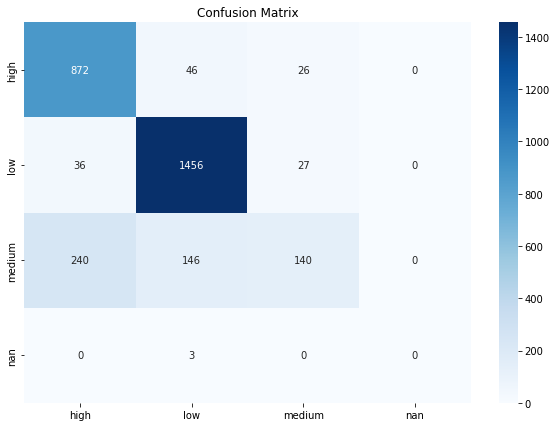

In [212]:
# decoded labels are all strings
actual_decoded_str = actual_decoded.astype(str)
predictions_decoded_str = np.array(predictions_decoded).astype(str)

# visualizing accuracy
accuracy = accuracy_score(actual_decoded_str, predictions_decoded_str)
print(f"Accuracy: {accuracy:.4f}")

# generating confusion matrix
conf_matrix = confusion_matrix(actual_decoded_str, predictions_decoded_str)

# plotting the confusion matrix
plt.figure(figsize=(10, 7))
tick_labels = label_contaminated_encoder.classes_
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels= tick_labels, yticklabels= tick_labels)
plt.title('Confusion Matrix')
#plt.xlabel('Predicted Label')
#plt.ylabel('True Label')
plt.show()

Accuracy: 0.8260


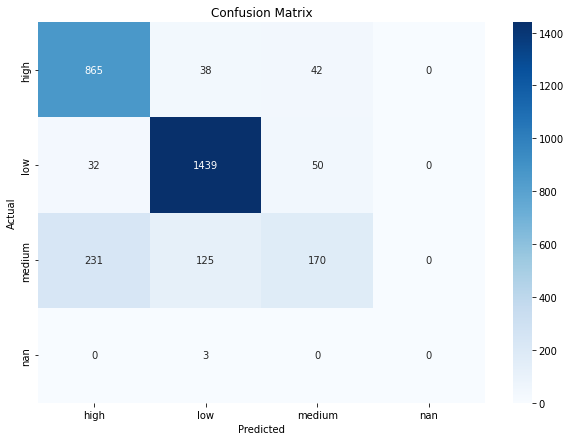

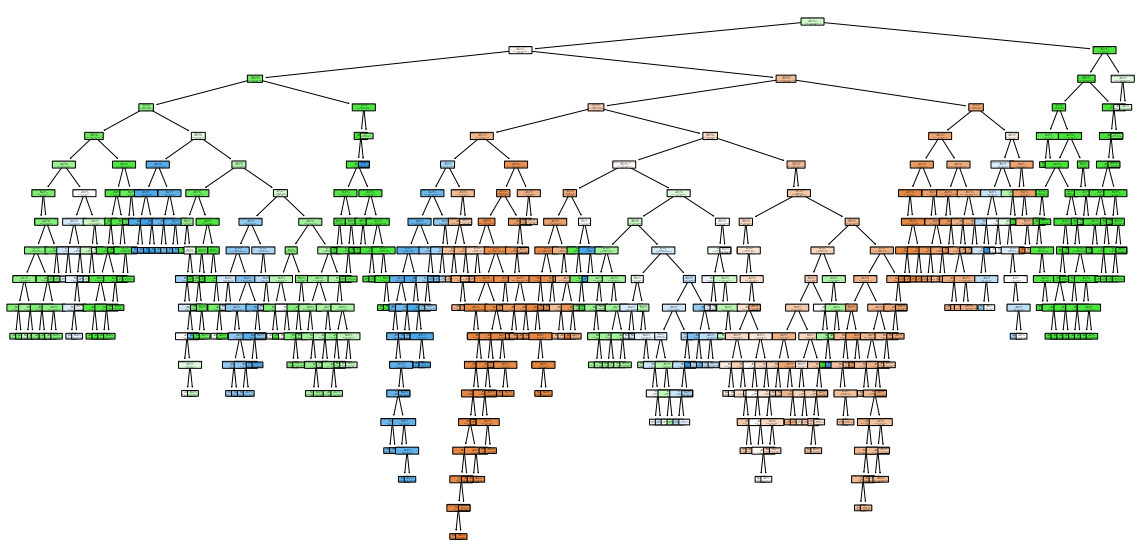

In [216]:
# trying CART 

# splitting data
X = chemicals_encoded_clean.drop(columns=['contaminated_water'])
y = chemicals_encoded_clean['contaminated_water']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# creating a DecisionTreeClassifier object
cart_model = DecisionTreeClassifier(random_state=42)

# fitting model to training data
cart_model.fit(X_train, y_train)

# predictions
predictions = cart_model.predict(X_test)

# calculating and visualizing accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

# generating confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

# plotting the confusion matrix
plt.figure(figsize=(10, 7))
tick_labels = label_contaminated_encoder.classes_  # decoded class names
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=tick_labels, yticklabels=tick_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# visualize decision tree
plt.figure(figsize=(20, 10))
plot_tree(cart_model,
          filled=True,
          rounded=True,
          class_names=tick_labels,
          feature_names=X_train.columns)
plt.show()
